Prices loaded: 1761 days


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2018-01-02,40.304180,59.450500,53.220631,78.870354,21.368668
2018-01-03,40.297165,60.209999,54.128632,79.237419,21.150000
2018-01-04,40.484333,60.479500,54.338890,79.934814,20.974667
2018-01-05,40.945263,61.457001,55.059437,80.925858,21.105333
2018-01-08,40.793186,62.343498,55.253826,81.008453,22.427334


Split events:


,Ticker,Date,Split Ratio
0,AAPL,1987-06-16,2.000
1,AAPL,2000-06-21,2.000
2,AAPL,2005-02-28,2.000
3,AAPL,2014-06-09,7.000
4,AAPL,2020-08-31,4.000
5,MSFT,1987-09-21,2.000
6,MSFT,1990-04-16,2.000
7,MSFT,1991-06-27,1.500
8,MSFT,1992-06-15,1.500
9,MSFT,1994-05-23,2.000



Running walk-forward backtests...


risk_parity: 100%|██████████| 753/753 [00:00<00:00, 1268.62it/s]



=== PERFORMANCE COMPARISON ===


,Strategy,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
0,Optimized (Max Sharpe),15.49%,31.68%,0.43,-49.66%
1,Equal Weight,16.45%,29.87%,0.48,-46.42%
2,Min Variance,15.78%,27.65%,0.50,-38.87%
3,Risk Parity,15.86%,28.22%,0.49,-43.05%
4,S&P 500,8.57%,17.49%,0.38,-25.43%



Key Insight:
The best risk-adjusted strategy was: Min Variance
Sharpe Ratio: 0.50


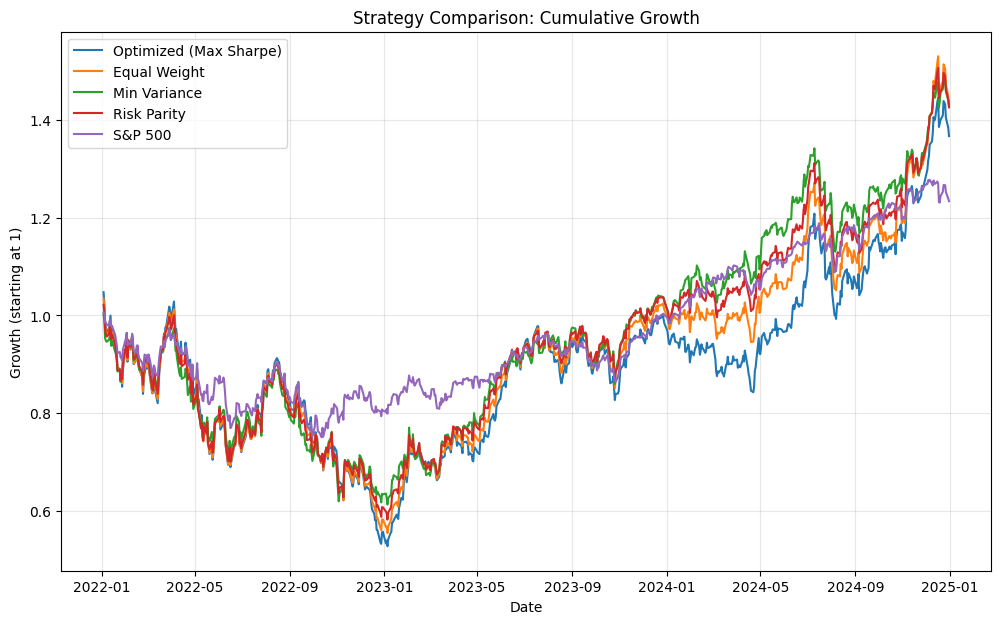

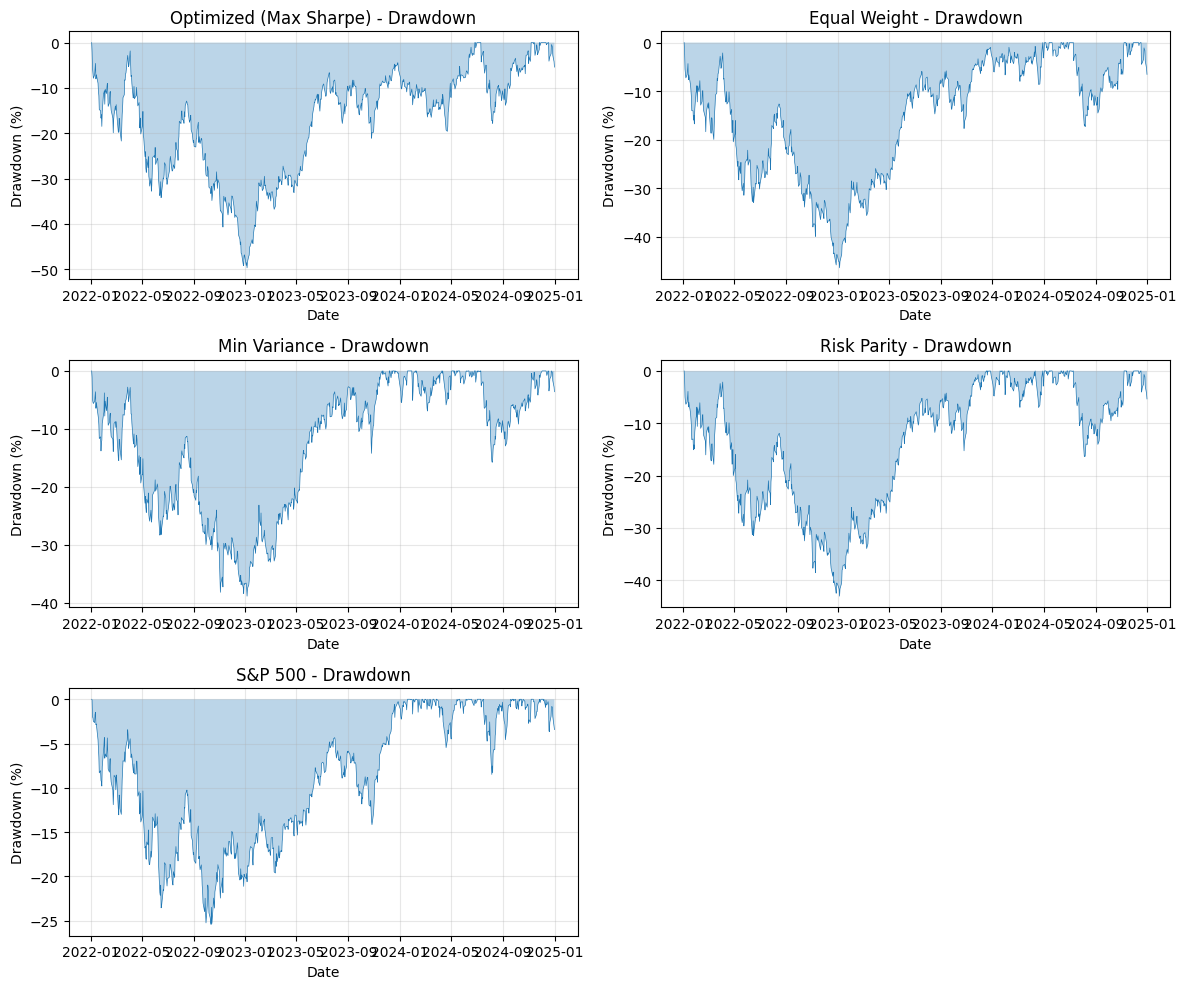

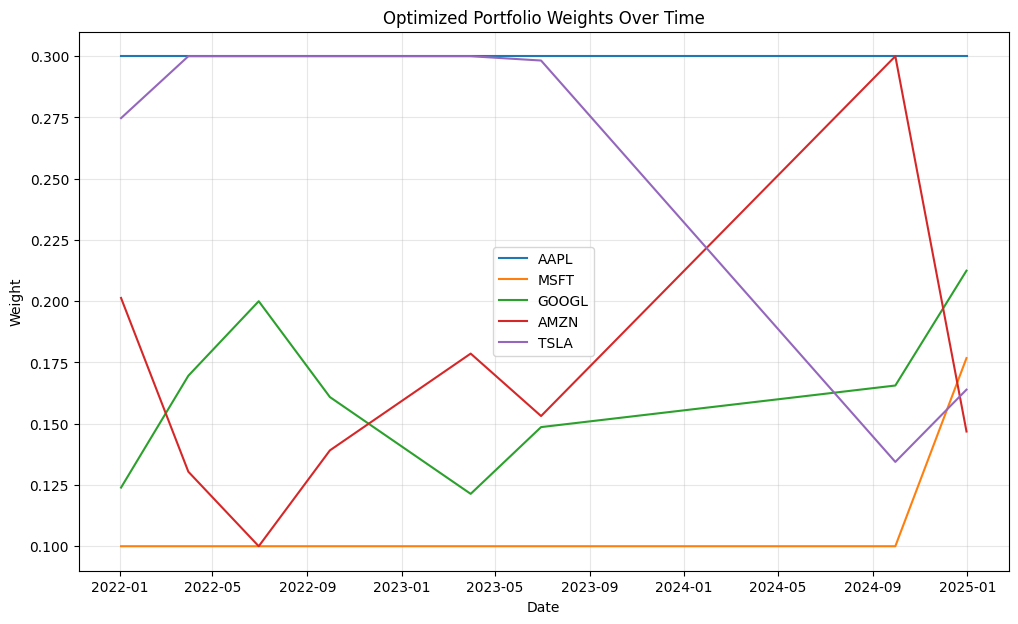

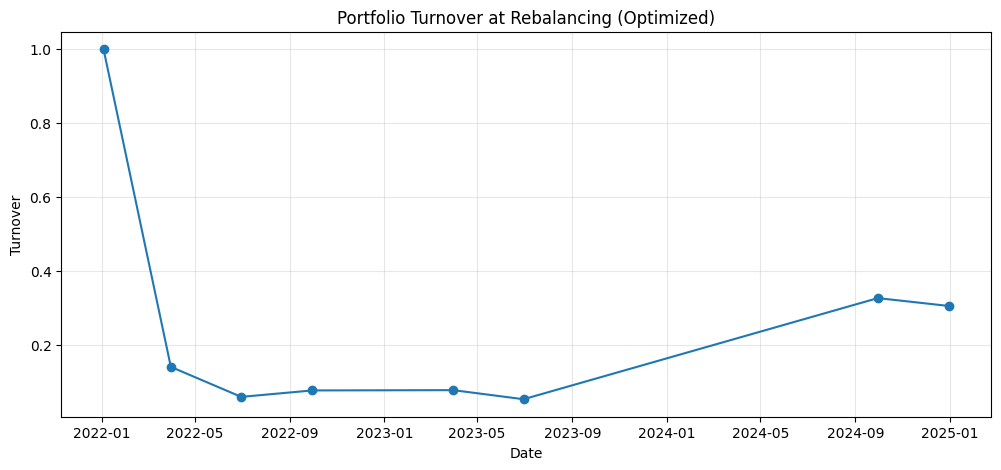


Saved files:
- strategy_performance_formatted.csv
- strategy_performance_raw.csv
- all_weights_history.csv
- all_rebalance_events.csv
- split_events.csv

Done!


In [1]:
# PISTOL Genesis AI Trade BOT
# PORTFOLIO OPTIMIZATION WITH WALK-FORWARD BACKTEST

!pip install yfinance scipy pandas numpy matplotlib tqdm -q

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm

# SETTINGS

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
benchmark = "^GSPC"

start_date = "2018-01-01"
end_date = "2025-01-01"

test_start = "2022-01-01"
test_end = "2024-12-31"

risk_free_rate = 0.02
max_weight = 0.40
transaction_cost = 0.001

train_window_days = 756
rebalance_frequency = "QE"  # Quarterly end

shrink_alpha = 0.5

# DATA DOWNLOAD

print("Downloading price data...")

prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"].dropna()

benchmark_prices = yf.download(
    benchmark,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"].dropna()

if isinstance(benchmark_prices, pd.DataFrame):
    benchmark_prices = benchmark_prices.iloc[:, 0]

print(f"Prices loaded: {prices.shape[0]} days")
display(prices.head())

# RETURNS

# auto_adjust=True uses adjusted prices.
# Separate dividend tax modelling is not included in this simplified version.

returns = prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

# SPLIT EVENTS

def check_splits(tickers):
    events = []

    for ticker in tickers:
        asset = yf.Ticker(ticker)
        splits = asset.splits

        if not splits.empty:
            splits.index = splits.index.tz_localize(None)

            for date, ratio in splits.items():
                events.append({
                    "Ticker": ticker,
                    "Date": date,
                    "Split Ratio": ratio
                })

    return pd.DataFrame(events)

split_events = check_splits(tickers)

print("Split events:")
display(split_events)

# OPTIMIZATION FUNCTIONS

def shrink_weights(weights, alpha=0.5):
    n = len(weights)
    equal = np.ones(n) / n
    return alpha * weights + (1 - alpha) * equal


def optimize_max_sharpe(train_returns, max_weight=0.40):
    n = train_returns.shape[1]

    mean_returns = train_returns.mean() * 252
    cov_matrix = train_returns.cov() * 252

    def negative_sharpe(weights):
        port_return = np.dot(weights, mean_returns)
        port_vol = np.sqrt(weights.T @ cov_matrix @ weights)

        if port_vol == 0:
            return 999

        return -((port_return - risk_free_rate) / port_vol)

    constraints = {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    }

    bounds = tuple((0, max_weight) for _ in range(n))
    init_weights = np.ones(n) / n

    result = minimize(
        negative_sharpe,
        init_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        return init_weights

    weights = result.x
    return weights / weights.sum()


def min_variance_weights(train_returns, max_weight=0.40):
    n = train_returns.shape[1]

    cov_matrix = train_returns.cov() * 252

    def portfolio_variance(weights):
        return weights.T @ cov_matrix @ weights

    constraints = {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    }

    bounds = tuple((0, max_weight) for _ in range(n))
    init_weights = np.ones(n) / n

    result = minimize(
        portfolio_variance,
        init_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        return init_weights

    weights = result.x
    return weights / weights.sum()


def risk_parity_weights(train_returns, max_weight=0.40):
    vols = train_returns.std()
    inv_vol = 1 / vols

    weights = inv_vol / inv_vol.sum()
    weights = np.clip(weights, 0, max_weight)
    weights = weights / weights.sum()

    return weights.values

# PERFORMANCE METRICS

def max_drawdown(cumulative):
    peak = cumulative.cummax()
    drawdown = cumulative / peak - 1
    return drawdown.min()


def annual_stats(r):
    if isinstance(r, pd.DataFrame):
        r = r.iloc[:, 0]

    r = r.dropna()

    if len(r) == 0:
        return np.nan, np.nan, np.nan, np.nan

    annual_return = r.mean() * 252
    annual_vol = r.std() * np.sqrt(252)

    if annual_vol == 0 or pd.isna(annual_vol):
        sharpe = np.nan
    else:
        sharpe = (annual_return - risk_free_rate) / annual_vol

    cumulative = (1 + r).cumprod()
    mdd = max_drawdown(cumulative)

    return annual_return, annual_vol, sharpe, mdd

# =========================
# WALK-FORWARD BACKTEST ENGINE
# =========================

def run_walk_forward(
    strategy_name,
    returns,
    tickers,
    test_start,
    test_end,
    train_window_days,
    rebalance_freq,
    max_weight,
    transaction_cost,
    shrink_alpha
):
    test_dates = returns.loc[test_start:test_end].index
    scheduled_dates = returns.loc[test_start:test_end].resample(rebalance_freq).first().index

    current_weights = np.ones(len(tickers)) / len(tickers)
    previous_weights = np.zeros(len(tickers))

    portfolio_returns = []
    weight_history = []
    event_history = []

    for i, date in enumerate(tqdm(test_dates, desc=strategy_name)):

        need_rebalance = (date in scheduled_dates) or (i == 0)
        cost = 0.0

        if need_rebalance:
            train_data = returns.loc[:date].tail(train_window_days)

            if len(train_data) < 252:
                new_weights = np.ones(len(tickers)) / len(tickers)
            else:
                if strategy_name == "optimized":
                    new_weights = optimize_max_sharpe(train_data, max_weight)
                    new_weights = shrink_weights(new_weights, shrink_alpha)

                elif strategy_name == "equal":
                    new_weights = np.ones(len(tickers)) / len(tickers)

                elif strategy_name == "min_variance":
                    new_weights = min_variance_weights(train_data, max_weight)

                elif strategy_name == "risk_parity":
                    new_weights = risk_parity_weights(train_data, max_weight)

                else:
                    raise ValueError(f"Unknown strategy: {strategy_name}")

                new_weights = new_weights / new_weights.sum()

            turnover = np.sum(np.abs(new_weights - previous_weights))
            cost = turnover * transaction_cost

            current_weights = new_weights.copy()
            previous_weights = new_weights.copy()

            weight_history.append(pd.DataFrame({
                "Date": date,
                "Ticker": tickers,
                "Weight": current_weights,
                "Strategy": strategy_name
            }))

            event_history.append({
                "Date": date,
                "Strategy": strategy_name,
                "Turnover": turnover,
                "Transaction Cost": cost
            })

        daily_asset_returns = returns.loc[date, tickers].values
        daily_return = np.sum(current_weights * daily_asset_returns) - cost

        portfolio_returns.append(pd.Series(daily_return, index=[date]))

    portfolio_returns = pd.concat(portfolio_returns)
    weight_history = pd.concat(weight_history) if weight_history else pd.DataFrame()
    event_history = pd.DataFrame(event_history)

    return portfolio_returns, weight_history, event_history

# RUN ALL STRATEGIES

print("\nRunning walk-forward backtests...")

strategies_to_run = [
    "optimized",
    "equal",
    "min_variance",
    "risk_parity"
]

results = {}

for strat in strategies_to_run:
    ret, w, ev = run_walk_forward(
        strat,
        returns,
        tickers,
        test_start,
        test_end,
        train_window_days,
        rebalance_frequency,
        max_weight,
        transaction_cost,
        shrink_alpha
    )

    results[strat] = {
        "returns": ret,
        "weights": w,
        "events": ev
    }

# =========================
# ALIGN BENCHMARK
# =========================

benchmark_test = benchmark_returns.reindex(results["optimized"]["returns"].index).dropna()
common_index = benchmark_test.index

for strat in results:
    results[strat]["returns"] = results[strat]["returns"].reindex(common_index).dropna()

all_returns = {
    "Optimized (Max Sharpe)": results["optimized"]["returns"],
    "Equal Weight": results["equal"]["returns"],
    "Min Variance": results["min_variance"]["returns"],
    "Risk Parity": results["risk_parity"]["returns"],
    "S&P 500": benchmark_test
}

# PERFORMANCE TABLES

raw_performance_rows = []

for name, ret_series in all_returns.items():
    ar, av, sh, mdd = annual_stats(ret_series)

    raw_performance_rows.append({
        "Strategy": name,
        "Annual Return": ar,
        "Annual Volatility": av,
        "Sharpe Ratio": sh,
        "Max Drawdown": mdd
    })

raw_perf_df = pd.DataFrame(raw_performance_rows)

perf_df = raw_perf_df.copy()
perf_df["Annual Return"] = perf_df["Annual Return"].map(lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")
perf_df["Annual Volatility"] = perf_df["Annual Volatility"].map(lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")
perf_df["Sharpe Ratio"] = perf_df["Sharpe Ratio"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "N/A")
perf_df["Max Drawdown"] = perf_df["Max Drawdown"].map(lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")

print("\n=== PERFORMANCE COMPARISON ===")
display(perf_df)

best_strategy = raw_perf_df.sort_values("Sharpe Ratio", ascending=False).iloc[0]

print("\nKey Insight:")
print(f"The best risk-adjusted strategy was: {best_strategy['Strategy']}")
print(f"Sharpe Ratio: {best_strategy['Sharpe Ratio']:.2f}")

# CHARTS

plt.figure(figsize=(12, 7))

for name, ret_series in all_returns.items():
    cumulative = (1 + ret_series).cumprod()
    plt.plot(cumulative.index, cumulative, label=name)

plt.title("Strategy Comparison: Cumulative Growth")
plt.xlabel("Date")
plt.ylabel("Growth (starting at 1)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 10))

for i, (name, ret_series) in enumerate(all_returns.items()):
    cum = (1 + ret_series).cumprod()
    peak = cum.cummax()
    dd = (cum / peak - 1) * 100

    plt.subplot(3, 2, i + 1)
    plt.fill_between(dd.index, dd, 0, alpha=0.3)
    plt.plot(dd.index, dd, linewidth=0.5)
    plt.title(f"{name} - Drawdown")
    plt.ylabel("Drawdown (%)")
    plt.xlabel("Date")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

opt_weights_pivot = results["optimized"]["weights"].pivot(
    index="Date",
    columns="Ticker",
    values="Weight"
)

if not opt_weights_pivot.empty:
    plt.figure(figsize=(12, 7))

    for ticker in tickers:
        if ticker in opt_weights_pivot.columns:
            plt.plot(opt_weights_pivot.index, opt_weights_pivot[ticker], label=ticker)

    plt.title("Optimized Portfolio Weights Over Time")
    plt.xlabel("Date")
    plt.ylabel("Weight")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

opt_events = results["optimized"]["events"]

if not opt_events.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(opt_events["Date"], opt_events["Turnover"], marker="o", linestyle="-")
    plt.title("Portfolio Turnover at Rebalancing (Optimized)")
    plt.xlabel("Date")
    plt.ylabel("Turnover")
    plt.grid(alpha=0.3)
    plt.show()

# SAVE RESULTS

all_weights = pd.concat(
    [results[s]["weights"] for s in strategies_to_run],
    ignore_index=True
)

all_events = pd.concat(
    [results[s]["events"] for s in strategies_to_run],
    ignore_index=True
)

perf_df.to_csv("strategy_performance_formatted.csv", index=False)
raw_perf_df.to_csv("strategy_performance_raw.csv", index=False)
all_weights.to_csv("all_weights_history.csv", index=False)
all_events.to_csv("all_rebalance_events.csv", index=False)
split_events.to_csv("split_events.csv", index=False)

print("\nSaved files:")
print("- strategy_performance_formatted.csv")
print("- strategy_performance_raw.csv")
print("- all_weights_history.csv")
print("- all_rebalance_events.csv")
print("- split_events.csv")

print("\nDone!")

In [2]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=split_events)

MessageError: Error: credential propagation was unsuccessful